In [1]:
import pandas as pd
df=pd.read_csv("C:/Users/dheve/OneDrive/Desktop/ML-project/predictive modeling for attoeny involvement in claims/Updated_Claimants_Dataset.csv")
df.head(10)

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS,Accident_Severity,Claim_Amount_Requested,Claim_Approval_Status,Settlement_Amount,Policy_Type,Driving_Record
0,5,0,0.0,1.0,0.0,50.0,2367.86,Severe,4497.19,1,3221.74,Third-Party,Clean
1,3,1,1.0,0.0,0.0,18.0,3746.41,Minor,6216.38,1,6166.17,Comprehensive,Clean
2,66,1,0.0,1.0,0.0,5.0,14282.43,Severe,17978.55,0,13804.61,Comprehensive,Minor Offenses
3,70,0,0.0,1.0,1.0,31.0,519.12,Severe,753.54,1,596.25,Comprehensive,Clean
4,96,1,0.0,1.0,0.0,30.0,1354.31,Minor,2167.42,0,1714.83,Comprehensive,Clean
5,97,0,1.0,1.0,0.0,35.0,2504.40,Minor,4553.78,0,3502.43,Third-Party,Minor Offenses
6,10,0,0.0,1.0,0.0,9.0,809.68,Severe,1017.38,0,712.62,Third-Party,Clean
7,36,0,1.0,1.0,0.0,34.0,3013.37,Moderate,4037.99,1,3710.12,Comprehensive,Clean
8,51,1,1.0,1.0,0.0,60.0,6936.94,Severe,11869.31,0,11751.25,Comprehensive,Major Offenses
9,55,1,0.0,1.0,0.0,NaN,4542.14,Severe,8717.78,1,6689.05,Comprehensive,Minor Offenses


In [2]:
df.describe()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS,Claim_Amount_Requested,Claim_Approval_Status,Settlement_Amount
count,1340.000000,1340.000000,1328.000000,1299.000000,1292.000000,1151.000000,1340.000000,1340.000000,1340.000000,1340.000000
mean,11202.001493,0.488806,0.558735,0.907621,0.017028,28.414422,6684.598149,10341.430276,0.480597,8787.805463
std,9512.750796,0.500061,0.496725,0.289671,0.129425,20.304451,3785.039412,5678.906970,0.499810,4942.577454
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,296.410000,562.760000,0.000000,424.520000
25%,4177.000000,0.000000,0.000000,1.000000,0.000000,9.000000,3414.052500,5308.890000,0.000000,4389.100000
50%,8756.500000,0.000000,1.000000,1.000000,0.000000,30.000000,6781.575000,10571.250000,0.000000,8898.245000
75%,15702.500000,1.000000,1.000000,1.000000,0.000000,43.000000,9708.882500,15291.665000,1.000000,12646.157500
max,34153.000000,1.000000,1.000000,1.000000,1.000000,95.000000,15794.810000,19988.570000,1.000000,19566.510000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CASENUM                 1340 non-null   int64  
 1   ATTORNEY                1340 non-null   int64  
 2   CLMSEX                  1328 non-null   float64
 3   CLMINSUR                1299 non-null   float64
 4   SEATBELT                1292 non-null   float64
 5   CLMAGE                  1151 non-null   float64
 6   LOSS                    1340 non-null   float64
 7   Accident_Severity       1340 non-null   object 
 8   Claim_Amount_Requested  1340 non-null   float64
 9   Claim_Approval_Status   1340 non-null   int64  
 10  Settlement_Amount       1340 non-null   float64
 11  Policy_Type             1340 non-null   object 
 12  Driving_Record          1340 non-null   object 
dtypes: float64(7), int64(3), object(3)
memory usage: 136.2+ KB


In [4]:
df.isnull().sum()

CASENUM                     0
ATTORNEY                    0
CLMSEX                     12
CLMINSUR                   41
SEATBELT                   48
CLMAGE                    189
LOSS                        0
Accident_Severity           0
Claim_Amount_Requested      0
Claim_Approval_Status       0
Settlement_Amount           0
Policy_Type                 0
Driving_Record              0
dtype: int64

In [5]:
# Replace missing values in CLMSEX with the mode
df['CLMSEX'] = df['CLMSEX'].fillna(df['CLMSEX'].mode()[0])
# Impute missing values in CLMAGE with the median
df['CLMAGE'] = df['CLMAGE'].fillna(df['CLMAGE'].median())

# Impute missing values in CLMINSUR with the mode
df['CLMINSUR'] = df['CLMINSUR'].fillna(df['CLMINSUR'].mode()[0])
df['SEATBELT'] = df['SEATBELT'].fillna(df['SEATBELT'].mode()[0])
# Step 1: Replace null values with "unknown"



In [6]:
df.isnull().sum()

CASENUM                   0
ATTORNEY                  0
CLMSEX                    0
CLMINSUR                  0
SEATBELT                  0
CLMAGE                    0
LOSS                      0
Accident_Severity         0
Claim_Amount_Requested    0
Claim_Approval_Status     0
Settlement_Amount         0
Policy_Type               0
Driving_Record            0
dtype: int64

In [7]:
corr=df.corr(numeric_only=True)
corr

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS,Claim_Amount_Requested,Claim_Approval_Status,Settlement_Amount
CASENUM,1.000000,0.011717,0.030946,0.042214,-0.009150,-0.002228,0.004575,0.012710,0.009361,0.007279
ATTORNEY,0.011717,1.000000,0.076564,0.076631,-0.055848,0.012223,0.021422,0.011072,0.000624,0.006963
CLMSEX,0.030946,0.076564,1.000000,0.065976,-0.016327,-0.023112,0.001327,-0.000169,-0.034236,0.007101
CLMINSUR,0.042214,0.076631,0.065976,1.000000,0.019953,0.045772,-0.005177,-0.002746,0.019206,0.002062
SEATBELT,-0.009150,-0.055848,-0.016327,0.019953,1.000000,-0.025914,0.000769,-0.008791,-0.018491,-0.015873
CLMAGE,-0.002228,0.012223,-0.023112,0.045772,-0.025914,1.000000,-0.024633,-0.019354,-0.009518,-0.014972
LOSS,0.004575,0.021422,0.001327,-0.005177,0.000769,-0.024633,1.000000,0.961385,0.054232,0.940719
Claim_Amount_Requested,0.012710,0.011072,-0.000169,-0.002746,-0.008791,-0.019354,0.961385,1.000000,0.054362,0.978993
Claim_Approval_Status,0.009361,0.000624,-0.034236,0.019206,-0.018491,-0.009518,0.054232,0.054362,1.000000,0.050316
Settlement_Amount,0.007279,0.006963,0.007101,0.002062,-0.015873,-0.014972,0.940719,0.978993,0.050316,1.000000


In [8]:
df[['CLMINSUR','CLMSEX','Driving_Record','LOSS','CLMAGE','ATTORNEY']]

,CLMINSUR,CLMSEX,Driving_Record,LOSS,CLMAGE,ATTORNEY
0,1.0,0.0,Clean,2367.86,50.0,0
1,0.0,1.0,Clean,3746.41,18.0,1
2,1.0,0.0,Minor Offenses,14282.43,5.0,1
3,1.0,0.0,Clean,519.12,31.0,0
4,1.0,0.0,Clean,1354.31,30.0,1
...,...,...,...,...,...,...
1335,1.0,0.0,Clean,11749.94,30.0,1
1336,1.0,1.0,Major Offenses,776.62,46.0,0
1337,1.0,1.0,Minor Offenses,13261.20,39.0,1
1338,0.0,1.0,Clean,9919.60,8.0,0


<Axes: >

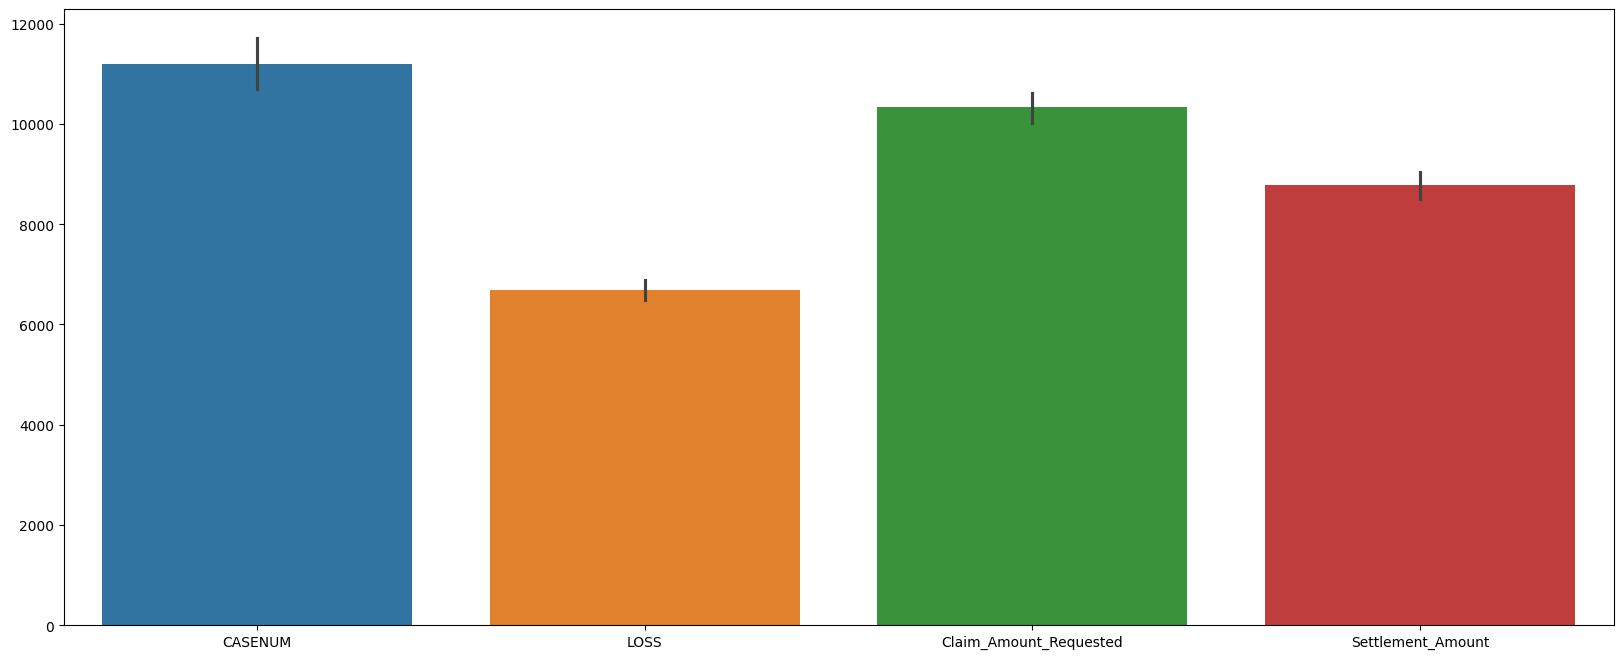

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(20,8))
data=df[['CASENUM','LOSS','Claim_Amount_Requested','Settlement_Amount']]
sns.barplot(data)

<Axes: >

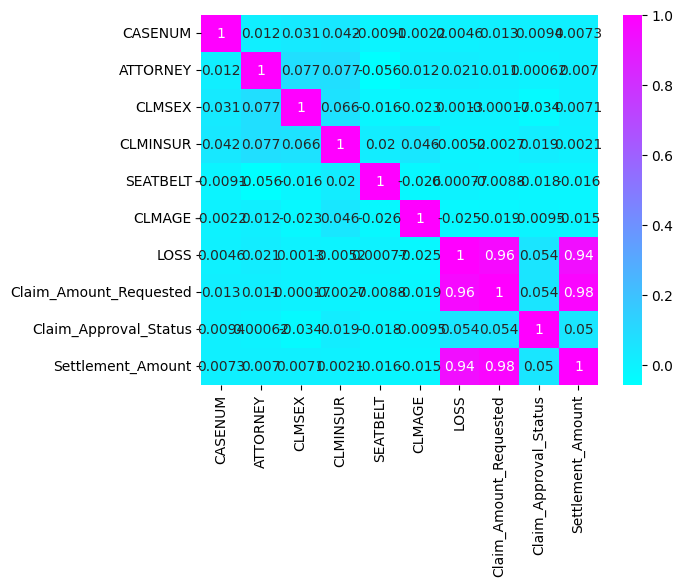

In [10]:
sns.heatmap(corr,cmap='cool',annot=True)

<Axes: xlabel='ATTORNEY', ylabel='count'>

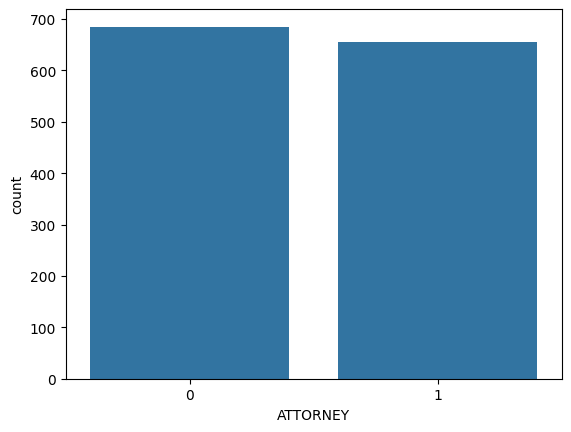

In [11]:
import seaborn as sns
sns.countplot(x='ATTORNEY', data=df)


<Axes: xlabel='SEATBELT'>

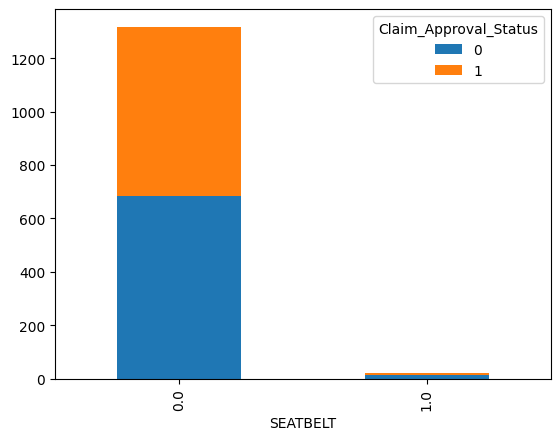

In [12]:
pd.crosstab(df['SEATBELT'], df['Claim_Approval_Status']).plot(kind='bar', stacked=True)


<Axes: ylabel='count'>

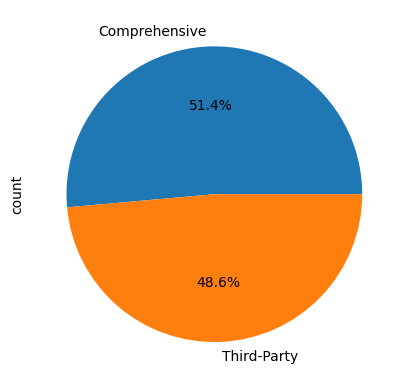

In [13]:
df['Policy_Type'].value_counts().plot(kind='pie', autopct='%1.1f%%')


<Axes: ylabel='count'>

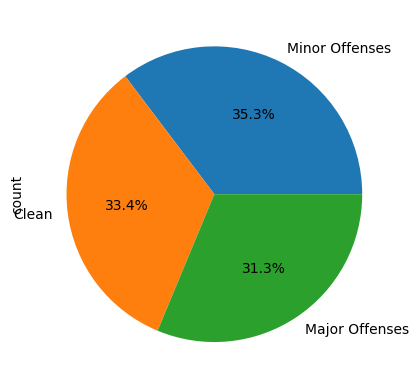

In [14]:

df['Driving_Record'].value_counts().plot(kind='pie', autopct='%1.1f%%')


<Axes: xlabel='CLMAGE', ylabel='Count'>

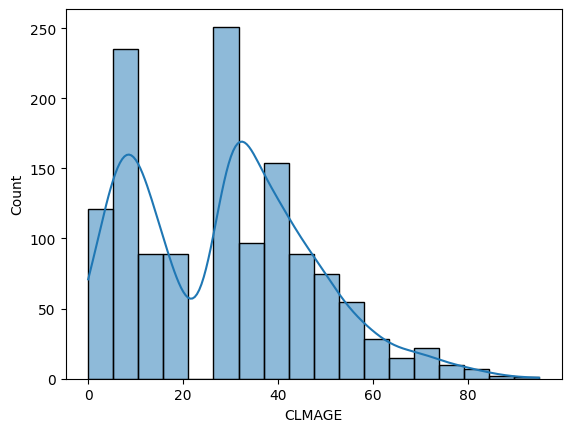

In [15]:
sns.histplot(df['CLMAGE'], kde=True)


<Axes: >

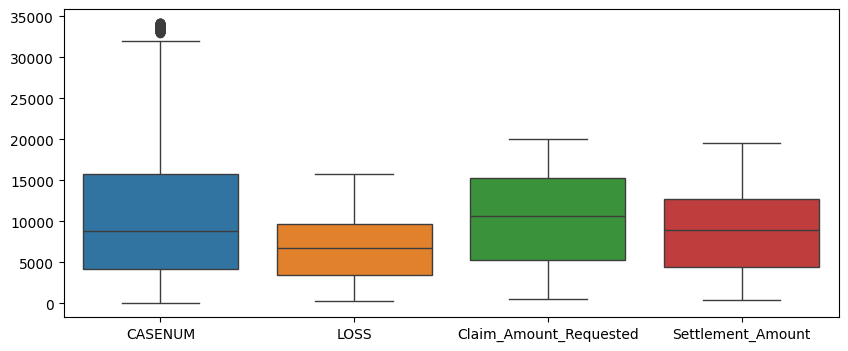

In [16]:
plt.figure(figsize=(10,4))
sns.boxplot(data)


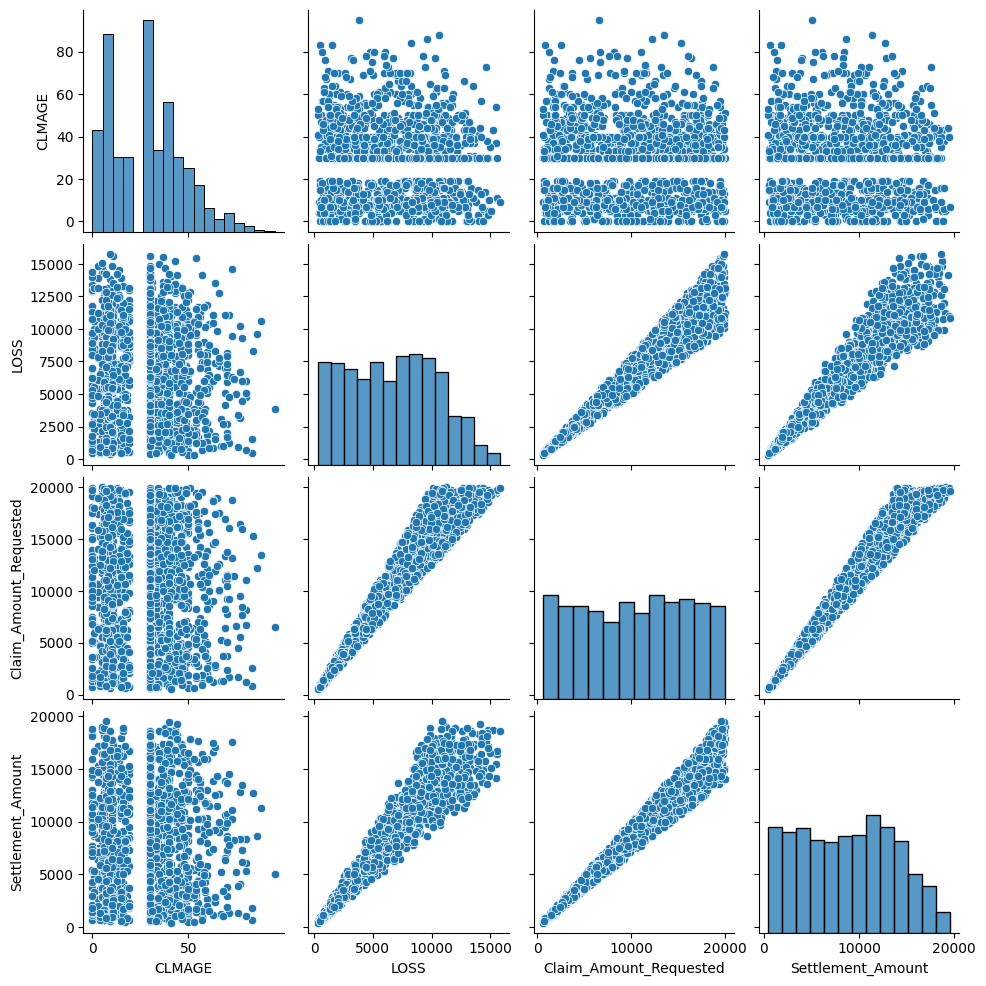

In [17]:
sns.pairplot(df[['CLMAGE', 'LOSS', 'Claim_Amount_Requested', 'Settlement_Amount']])


<Axes: xlabel='ATTORNEY', ylabel='count'>

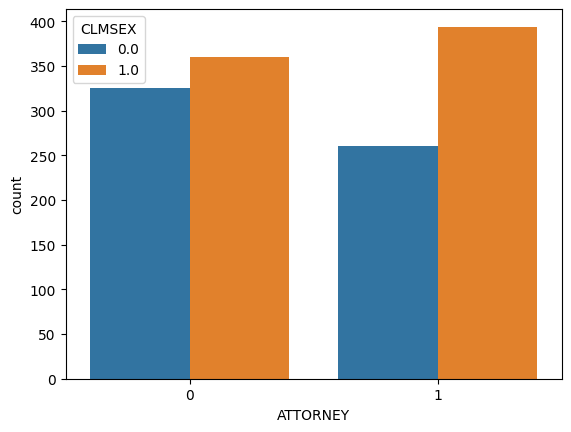

In [18]:
sns.countplot(x='ATTORNEY', hue='CLMSEX', data=df)


<Axes: xlabel='SEATBELT', ylabel='count'>

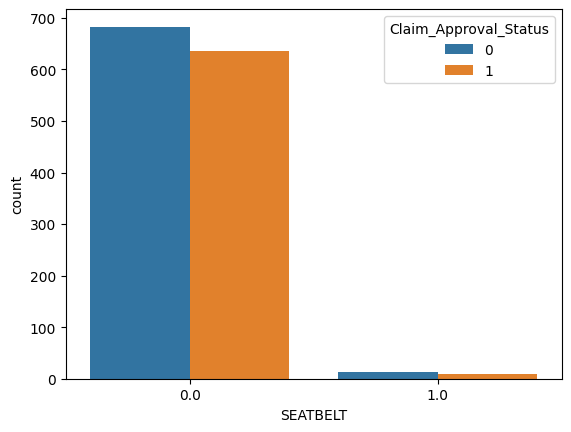

In [19]:
sns.countplot(x='SEATBELT', hue='Claim_Approval_Status', data=df)


In [20]:

print(df['ATTORNEY'].value_counts())


ATTORNEY
0    685
1    655
Name: count, dtype: int64


In [21]:
df.head(10)

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS,Accident_Severity,Claim_Amount_Requested,Claim_Approval_Status,Settlement_Amount,Policy_Type,Driving_Record
0,5,0,0.0,1.0,0.0,50.0,2367.86,Severe,4497.19,1,3221.74,Third-Party,Clean
1,3,1,1.0,0.0,0.0,18.0,3746.41,Minor,6216.38,1,6166.17,Comprehensive,Clean
2,66,1,0.0,1.0,0.0,5.0,14282.43,Severe,17978.55,0,13804.61,Comprehensive,Minor Offenses
3,70,0,0.0,1.0,1.0,31.0,519.12,Severe,753.54,1,596.25,Comprehensive,Clean
4,96,1,0.0,1.0,0.0,30.0,1354.31,Minor,2167.42,0,1714.83,Comprehensive,Clean
5,97,0,1.0,1.0,0.0,35.0,2504.40,Minor,4553.78,0,3502.43,Third-Party,Minor Offenses
6,10,0,0.0,1.0,0.0,9.0,809.68,Severe,1017.38,0,712.62,Third-Party,Clean
7,36,0,1.0,1.0,0.0,34.0,3013.37,Moderate,4037.99,1,3710.12,Comprehensive,Clean
8,51,1,1.0,1.0,0.0,60.0,6936.94,Severe,11869.31,0,11751.25,Comprehensive,Major Offenses
9,55,1,0.0,1.0,0.0,30.0,4542.14,Severe,8717.78,1,6689.05,Comprehensive,Minor Offenses


In [24]:
import pandas as pd

# Compute the correlation of all columns with the 'ATTORNEY' column
correlations = df.corr(numeric_only=True)['ATTORNEY']

# Sort correlations in descending order
sorted_correlations = correlations.sort_values(ascending=False)

# Display the sorted correlations
print(sorted_correlations)


ATTORNEY                  1.000000
CLMINSUR                  0.076631
CLMSEX                    0.076564
LOSS                      0.021422
CLMAGE                    0.012223
CASENUM                   0.011717
Claim_Amount_Requested    0.011072
Settlement_Amount         0.006963
Claim_Approval_Status     0.000624
settlement_ratio         -0.018485
SEATBELT                 -0.055848
Name: ATTORNEY, dtype: float64


In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

# --- Encode Target Variable ('ATTORNEY') ---
label_encoder = LabelEncoder()
df['ATTORNEY'] = label_encoder.fit_transform(df['ATTORNEY'])

# --- Split the data into features and target variable ---
X = df[['Accident_Severity', 'Policy_Type', 'Driving_Record', 'CLMSEX', 'Claim_Approval_Status']]  # Features
y = df['ATTORNEY']  # Target variable

# Encode categorical features in X
categorical_features = ['Accident_Severity', 'Policy_Type', 'Driving_Record']
for col in categorical_features:
    X[col] = label_encoder.fit_transform(X[col])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Perform Chi-Square test for feature selection ---
chi2_stat, p_val = chi2(X_train, y_train)

# Store the chi-square values and p-values for each feature
chi2_results = pd.DataFrame({
    'Feature': X_train.columns,
    'Chi-Square Statistic': chi2_stat,
    'P-Value': p_val
})

# Sort results by P-Value
chi2_results_sorted = chi2_results.sort_values(by='P-Value')

# Display the sorted results
print(chi2_results_sorted)


                 Feature  Chi-Square Statistic   P-Value
3                 CLMSEX              3.158841  0.075517
0      Accident_Severity              0.489867  0.483987
2         Driving_Record              0.009849  0.920946
1            Policy_Type              0.003834  0.950625
4  Claim_Approval_Status              0.000007  0.997893


C:\Users\dheve\AppData\Local\Temp\ipykernel_27440\3399360941.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = label_encoder.fit_transform(X[col])
C:\Users\dheve\AppData\Local\Temp\ipykernel_27440\3399360941.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = label_encoder.fit_transform(X[col])
C:\Users\dheve\AppData\Local\Temp\ipykernel_27440\3399360941.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_ind

In [26]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd

# Create a LabelEncoder instance
label_encoder = LabelEncoder()

# --- Label Encoding for all categorical columns ---
categorical_columns = ['Policy_Type', 'Accident_Severity', 'Driving_Record']  # List of categorical columns
for column in categorical_columns:
    df[column + '_Encoded'] = label_encoder.fit_transform(df[column])

# --- Dropping Original Categorical Columns ---
df = df.drop(categorical_columns, axis=1)

# --- Scaling Numerical Features ---


# --- Final Processed DataFrame ---



In [27]:
df.head()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS,Claim_Amount_Requested,Claim_Approval_Status,Settlement_Amount,settlement_ratio,age_group,Policy_Type_Encoded,Accident_Severity_Encoded,Driving_Record_Encoded
0,5,0,0.0,1.0,0.0,50.0,2367.86,4497.19,1,3221.74,0.716390,"(45, 55]",1,2,0
1,3,1,1.0,0.0,0.0,18.0,3746.41,6216.38,1,6166.17,0.991923,"(0, 25]",0,0,0
2,66,1,0.0,1.0,0.0,5.0,14282.43,17978.55,0,13804.61,0.767838,"(0, 25]",0,2,2
3,70,0,0.0,1.0,1.0,31.0,519.12,753.54,1,596.25,0.791265,"(25, 35]",0,2,0
4,96,1,0.0,1.0,0.0,30.0,1354.31,2167.42,0,1714.83,0.791185,"(25, 35]",0,0,0


In [28]:
df.head(10)

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS,Claim_Amount_Requested,Claim_Approval_Status,Settlement_Amount,settlement_ratio,age_group,Policy_Type_Encoded,Accident_Severity_Encoded,Driving_Record_Encoded
0,5,0,0.0,1.0,0.0,50.0,2367.86,4497.19,1,3221.74,0.716390,"(45, 55]",1,2,0
1,3,1,1.0,0.0,0.0,18.0,3746.41,6216.38,1,6166.17,0.991923,"(0, 25]",0,0,0
2,66,1,0.0,1.0,0.0,5.0,14282.43,17978.55,0,13804.61,0.767838,"(0, 25]",0,2,2
3,70,0,0.0,1.0,1.0,31.0,519.12,753.54,1,596.25,0.791265,"(25, 35]",0,2,0
4,96,1,0.0,1.0,0.0,30.0,1354.31,2167.42,0,1714.83,0.791185,"(25, 35]",0,0,0
5,97,0,1.0,1.0,0.0,35.0,2504.40,4553.78,0,3502.43,0.769126,"(25, 35]",1,0,2
6,10,0,0.0,1.0,0.0,9.0,809.68,1017.38,0,712.62,0.700446,"(0, 25]",1,2,0
7,36,0,1.0,1.0,0.0,34.0,3013.37,4037.99,1,3710.12,0.918804,"(25, 35]",0,1,0
8,51,1,1.0,1.0,0.0,60.0,6936.94,11869.31,0,11751.25,0.990053,"(55, 100]",0,2,1
9,55,1,0.0,1.0,0.0,30.0,4542.14,8717.78,1,6689.05,0.767288,"(25, 35]",0,2,2


In [29]:
X

,Accident_Severity,Policy_Type,Driving_Record,CLMSEX,Claim_Approval_Status
0,2,1,0,0.0,1
1,0,0,0,1.0,1
2,2,0,2,0.0,0
3,2,0,0,0.0,1
4,0,0,0,0.0,0
...,...,...,...,...,...
1335,1,0,0,0.0,0
1336,1,1,1,1.0,0
1337,2,1,2,1.0,1
1338,0,1,0,1.0,1


In [30]:
df.head(4)

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS,Claim_Amount_Requested,Claim_Approval_Status,Settlement_Amount,settlement_ratio,age_group,Policy_Type_Encoded,Accident_Severity_Encoded,Driving_Record_Encoded
0,5,0,0.0,1.0,0.0,50.0,2367.86,4497.19,1,3221.74,0.716390,"(45, 55]",1,2,0
1,3,1,1.0,0.0,0.0,18.0,3746.41,6216.38,1,6166.17,0.991923,"(0, 25]",0,0,0
2,66,1,0.0,1.0,0.0,5.0,14282.43,17978.55,0,13804.61,0.767838,"(0, 25]",0,2,2
3,70,0,0.0,1.0,1.0,31.0,519.12,753.54,1,596.25,0.791265,"(25, 35]",0,2,0


In [31]:
from sklearn.model_selection import train_test_split
x = df[['CLMINSUR', 'CLMSEX', 'LOSS','CLMAGE']]
y = df['ATTORNEY']  # Target variable


# Split the dataset into training and testing sets (80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#shape of x_train and y_train
print(x_train.shape, y_train.shape)  # Both should have the same number of rows


(1072, 4) (1072,)


In [32]:
scaler = StandardScaler()
# Specify the numerical columns to scale (if any)
# Assuming the numeric columns are not being encoded, so you should specify them manually
numerical_cols = ['CLMAGE', 'LOSS', 'Claim_Amount_Requested', 'Settlement_Amount']


# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the numerical columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])


In [33]:
df.head()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS,Claim_Amount_Requested,Claim_Approval_Status,Settlement_Amount,settlement_ratio,age_group,Policy_Type_Encoded,Accident_Severity_Encoded,Driving_Record_Encoded
0,5,0,0.0,1.0,0.0,1.135184,-1.140900,-1.029498,1,-1.126567,0.716390,"(45, 55]",1,2,0
1,3,1,1.0,0.0,0.0,-0.565311,-0.776553,-0.726652,1,-0.530617,0.991923,"(0, 25]",0,0,0
2,66,1,0.0,1.0,0.0,-1.256138,2.008082,1.345324,0,1.015397,0.767838,"(0, 25]",0,2,2
3,70,0,0.0,1.0,1.0,0.125515,-1.629515,-1.688964,1,-1.657964,0.791265,"(25, 35]",0,2,0
4,96,1,0.0,1.0,0.0,0.072374,-1.408777,-1.439901,0,-1.431564,0.791185,"(25, 35]",0,0,0


In [43]:
import pickle
import catboost
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

model = CatBoostClassifier(random_state=42, iterations=1000, learning_rate=0.1)
model.fit(x_train, y_train)

# Save the trained model to a file using pickle
with open('catboost_model.pkl', 'wb') as model_file:
    pickle.dump(model, model_file)

# Save feature importance (you can modify this according to your actual model)
feature_importance = pd.DataFrame({
    'feature': ['CLMINSUR', 'CLMSEX','LOSS', 'CLMAGE'],
    'importance': model.get_feature_importance()
})

# Save feature importance to a file using pickle
with open('feature_importance.pkl', 'wb') as importance_file:
    pickle.dump(feature_importance, importance_file)

0:	learn: 0.6892407	total: 3.46ms	remaining: 3.46s
1:	learn: 0.6849951	total: 6.43ms	remaining: 3.21s
2:	learn: 0.6844069	total: 8.18ms	remaining: 2.72s
3:	learn: 0.6820635	total: 10.9ms	remaining: 2.71s
4:	learn: 0.6795343	total: 15.4ms	remaining: 3.06s
5:	learn: 0.6769511	total: 18.6ms	remaining: 3.07s
6:	learn: 0.6741781	total: 21.7ms	remaining: 3.07s
7:	learn: 0.6701955	total: 26ms	remaining: 3.22s
8:	learn: 0.6687895	total: 29.1ms	remaining: 3.2s
9:	learn: 0.6669769	total: 33.3ms	remaining: 3.3s
10:	learn: 0.6658903	total: 36.5ms	remaining: 3.28s
11:	learn: 0.6632320	total: 40.2ms	remaining: 3.31s
12:	learn: 0.6622441	total: 44.2ms	remaining: 3.35s
13:	learn: 0.6608209	total: 47.5ms	remaining: 3.34s
14:	learn: 0.6589814	total: 50.8ms	remaining: 3.33s
15:	learn: 0.6581017	total: 53.9ms	remaining: 3.31s
16:	learn: 0.6562326	total: 56.9ms	remaining: 3.29s
17:	learn: 0.6542512	total: 59.9ms	remaining: 3.27s
18:	learn: 0.6514700	total: 62.8ms	remaining: 3.24s
19:	learn: 0.6496631	total

In [35]:
y_pred = model.predict(x_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.5970149253731343
Confusion Matrix:
 [[78 50]
 [58 82]]
Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.61      0.59       128
           1       0.62      0.59      0.60       140

    accuracy                           0.60       268
   macro avg       0.60      0.60      0.60       268
weighted avg       0.60      0.60      0.60       268



In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Initialize the model

model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
model.fit(x_train, y_train)

# Make predictions
y_pred = model.predict(x_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.6007462686567164
Confusion Matrix:
 [[78 50]
 [57 83]]
Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.61      0.59       128
           1       0.62      0.59      0.61       140

    accuracy                           0.60       268
   macro avg       0.60      0.60      0.60       268
weighted avg       0.60      0.60      0.60       268



In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize the model
model = LogisticRegression()

# Train the model
model.fit(x_train, y_train)

# Make predictions
y_pred = model.predict(x_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.5447761194029851
Confusion Matrix:
 [[66 62]
 [60 80]]
Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.52      0.52       128
           1       0.56      0.57      0.57       140

    accuracy                           0.54       268
   macro avg       0.54      0.54      0.54       268
weighted avg       0.54      0.54      0.54       268



In [38]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

# Train the model
# Initialize the model
model = xgb.XGBClassifier(random_state=42)

# Train the model
model.fit(x_train, y_train)

# Make predictions
y_pred = model.predict(x_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.5373134328358209
Confusion Matrix:
 [[66 62]
 [62 78]]
Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.52      0.52       128
           1       0.56      0.56      0.56       140

    accuracy                           0.54       268
   macro avg       0.54      0.54      0.54       268
weighted avg       0.54      0.54      0.54       268



In [39]:
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")


x_train shape: (1072, 4)
y_train shape: (1072,)


In [40]:
df[['CLMINSUR','CLMSEX','Accident_Severity_Encoded','LOSS','CLMAGE','ATTORNEY']]

,CLMINSUR,CLMSEX,Accident_Severity_Encoded,LOSS,CLMAGE,ATTORNEY
0,1.0,0.0,2,-1.140900,1.135184,0
1,0.0,1.0,0,-0.776553,-0.565311,1
2,1.0,0.0,2,2.008082,-1.256138,1
3,1.0,0.0,2,-1.629515,0.125515,0
4,1.0,0.0,0,-1.408777,0.072374,1
...,...,...,...,...,...,...
1335,1.0,0.0,1,1.338753,0.072374,1
1336,1.0,1.0,1,-1.561459,0.922622,0
1337,1.0,1.0,2,1.738174,0.550638,1
1338,0.0,1.0,0,0.855000,-1.096716,0


In [41]:
X_train

,Accident_Severity,Policy_Type,Driving_Record,CLMSEX,Claim_Approval_Status
1148,1,1,1,1.0,1
807,1,0,2,0.0,1
1287,1,1,2,0.0,1
590,2,1,2,1.0,1
1188,2,1,1,1.0,0
...,...,...,...,...,...
1095,0,1,1,0.0,0
1130,1,1,2,1.0,0
1294,1,0,0,1.0,1
860,1,1,1,1.0,1


In [42]:
y_train

1148    1
807     0
1287    1
590     1
1188    0
       ..
1095    0
1130    0
1294    0
860     0
1126    1
Name: ATTORNEY, Length: 1072, dtype: int64